# Analisa Data Menggunakan Regresi Linier (A)

Notebook ini dibuat untuk menyelesaikan tugas **Analisa Data Menggunakan Regresi Linier** berdasarkan titik-titik pada gambar GeoGebra.

Data titik yang digunakan:

| Titik | x | y |
|---|---:|---:|
| A | 2 | 2 |
| B | 4 | 3 |
| C | 5 | 5 |
| D | 3 | 4 |
| E | 3 | 3 |
| F | 4 | 5 |
| G | 5 | 6 |

Tujuan notebook ini:

1. Membuat program regresi linier menggunakan `sklearn`.
2. Menghitung koefisien regresi secara analitik/manual.
3. Menghitung koefisien regresi menggunakan rumus matriks:

$$
\hat{\beta} = (X^T X)^{-1}X^TY
$$

4. Menampilkan visualisasi yang diperlukan: scatter plot, garis regresi, residual/error, dan evaluasi sederhana.

## 1. Import library

Library yang digunakan:

- `numpy` untuk perhitungan numerik dan matriks.
- `pandas` untuk membuat tabel data.
- `matplotlib` untuk visualisasi grafik.
- `LinearRegression` dari `sklearn.linear_model` untuk membuat model regresi linier.
- `metrics` dari `sklearn` untuk menghitung evaluasi model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn import metrics

## 2. Memasukkan data dari GeoGebra

Data diambil dari titik-titik pada gambar GeoGebra:

$$
A=(2,2), B=(4,3), C=(5,5), D=(3,4), E=(3,3), F=(4,5), G=(5,6)
$$

In [2]:
# Data titik dari GeoGebra
data = {
    "Titik": ["A", "B", "C", "D", "E", "F", "G"],
    "x": [2, 4, 5, 3, 3, 4, 5],
    "y": [2, 3, 5, 4, 3, 5, 6]
}

df = pd.DataFrame(data)
df

,Titik,x,y
0,A,2,2
1,B,4,3
2,C,5,5
3,D,3,4
4,E,3,3
5,F,4,5
6,G,5,6


## 3. Visualisasi data awal

Sebelum membuat model regresi, data divisualisasikan terlebih dahulu dalam bentuk **scatter plot**.

Tujuannya adalah melihat pola hubungan antara variabel $x$ dan variabel $y$.

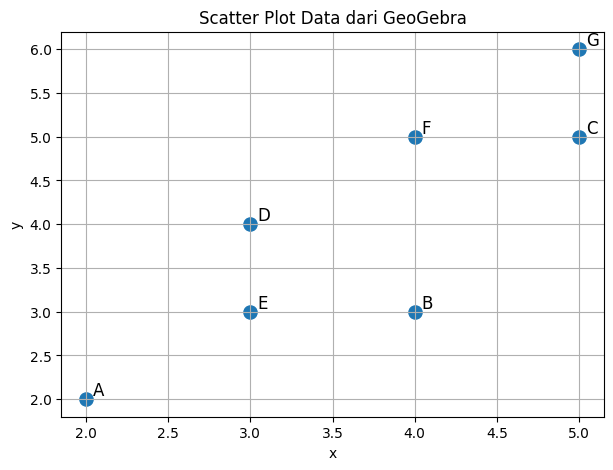

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(df["x"], df["y"], s=90)

# Menambahkan label A-G pada setiap titik
for i, row in df.iterrows():
    plt.text(row["x"] + 0.04, row["y"] + 0.04, row["Titik"], fontsize=12)

plt.title("Scatter Plot Data dari GeoGebra")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

Dari grafik terlihat bahwa ketika nilai $x$ naik, nilai $y$ juga cenderung naik. Karena pola data terlihat memiliki kecenderungan linier, maka regresi linier cocok digunakan.

## 4. Bentuk umum regresi linier

Regresi linier sederhana memiliki bentuk:

$$
y = mx + b
$$

Keterangan:

- \(y\) adalah nilai target/respons.
- \(x\) adalah variabel input/fitur.
- \(m\) adalah koefisien regresi atau slope.
- \(b\) adalah intercept atau konstanta.

Dalam notasi lain, persamaan dapat ditulis:

$$
y = \beta_0 + \beta_1x
$$

dengan:

- \(\beta_0 = b\)
- \(\beta_1 = m\)

## 5. Menghitung koefisien regresi secara analitik/manual

Rumus slope:

$$
m = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}
$$

Rumus intercept:

$$
b = \bar{y} - m\bar{x}
$$

Langkah pertama adalah menghitung rata-rata $x$ dan $y$.

In [4]:
x = df["x"].values
y = df["y"].values

x_mean = np.mean(x)
y_mean = np.mean(y)

print("Rata-rata x =", x_mean)
print("Rata-rata y =", y_mean)

Rata-rata x = 3.7142857142857144
Rata-rata y = 4.0


Setelah rata-rata diperoleh, buat tabel bantu untuk menghitung:

$$
(x_i-\bar{x}), \quad (y_i-\bar{y}), \quad (x_i-\bar{x})(y_i-\bar{y}), \quad (x_i-\bar{x})^2
$$

In [5]:
df_manual = df.copy()
df_manual["x - x_mean"] = df_manual["x"] - x_mean
df_manual["y - y_mean"] = df_manual["y"] - y_mean
df_manual["(x - x_mean)(y - y_mean)"] = df_manual["x - x_mean"] * df_manual["y - y_mean"]
df_manual["(x - x_mean)^2"] = df_manual["x - x_mean"] ** 2

df_manual

,Titik,x,y,x - x_mean,y - y_mean,(x - x_mean)(y - y_mean),(x - x_mean)^2
0,A,2,2,-1.714286,-2.0,3.428571,2.938776
1,B,4,3,0.285714,-1.0,-0.285714,0.081633
2,C,5,5,1.285714,1.0,1.285714,1.653061
3,D,3,4,-0.714286,0.0,-0.000000,0.510204
4,E,3,3,-0.714286,-1.0,0.714286,0.510204
5,F,4,5,0.285714,1.0,0.285714,0.081633
6,G,5,6,1.285714,2.0,2.571429,1.653061


In [6]:
pembilang = np.sum((x - x_mean) * (y - y_mean))
penyebut = np.sum((x - x_mean) ** 2)

m_manual = pembilang / penyebut
b_manual = y_mean - m_manual * x_mean

print("Jumlah (x - x_mean)(y - y_mean) =", pembilang)
print("Jumlah (x - x_mean)^2 =", penyebut)
print("Slope / koefisien m =", m_manual)
print("Intercept b =", b_manual)
print(f"Persamaan regresi: y = {m_manual:.6f}x + {b_manual:.6f}")

Jumlah (x - x_mean)(y - y_mean) = 8.0
Jumlah (x - x_mean)^2 = 7.42857142857143
Slope / koefisien m = 1.0769230769230766
Intercept b = 8.881784197001252e-16
Persamaan regresi: y = 1.076923x + 0.000000


Hasil perhitungan manual menunjukkan:

$$
m = 1.076923
$$

$$
b \approx 0
$$

Jadi persamaan regresi liniernya adalah:

$$
\hat{y} = 1.076923x
$$

## 6. Menghitung koefisien menggunakan rumus matriks

Rumus yang digunakan pada tugas:

$$
\hat{\beta} = (X^T X)^{-1} X^T Y
$$

Karena bentuk model adalah:

$$
y = \beta_0 + \beta_1x
$$

maka matriks \(X\) dibuat dengan dua kolom:

1. Kolom pertama berisi angka 1 sebagai konstanta/intercept.
2. Kolom kedua berisi nilai \(x\).

Sehingga:

$$
X =
\begin{bmatrix}
1 & 2\\
1 & 4\\
1 & 5\\
1 & 3\\
1 & 3\\
1 & 4\\
1 & 5
\end{bmatrix}
$$

dan:

$$
Y =
\begin{bmatrix}
2\\
3\\
5\\
4\\
3\\
5\\
6
\end{bmatrix}
$$

In [7]:
# Membentuk matriks X dan Y
X_matrix = np.column_stack((np.ones(len(x)), x))
Y_matrix = y.reshape(-1, 1)

print("Matriks X:")
print(X_matrix)

print("\nMatriks Y:")
print(Y_matrix)

Matriks X:
[[1. 2.]
 [1. 4.]
 [1. 5.]
 [1. 3.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]

Matriks Y:
[[2]
 [3]
 [5]
 [4]
 [3]
 [5]
 [6]]


In [8]:
XtX = X_matrix.T @ X_matrix
XtY = X_matrix.T @ Y_matrix
XtX_inv = np.linalg.inv(XtX)

beta = XtX_inv @ XtY

print("X^T X:")
print(XtX)

print("\n(X^T X)^-1:")
print(XtX_inv)

print("\nX^T Y:")
print(XtY)

print("\nBeta:")
print(beta)

print("\nIntercept beta_0 =", beta[0][0])
print("Slope beta_1 =", beta[1][0])

X^T X:
[[  7.  26.]
 [ 26. 104.]]

(X^T X)^-1:
[[ 2.         -0.5       ]
 [-0.5         0.13461538]]

X^T Y:
[[ 28.]
 [112.]]

Beta:
[[0.        ]
 [1.07692308]]

Intercept beta_0 = 0.0
Slope beta_1 = 1.0769230769230766


Dari hasil matriks diperoleh:

$$
\hat{\beta} =
\begin{bmatrix}
0\\
1.076923
\end{bmatrix}
$$

Artinya:

$$
\beta_0 = 0
$$

$$
\beta_1 = 1.076923
$$

Maka:

$$
\hat{y} = 0 + 1.076923x
$$

atau:

$$
\hat{y} = 1.076923x
$$

## 7. Menghitung regresi linier menggunakan Scikit-Learn

Bagian ini menggunakan library:

```python
from sklearn.linear_model import LinearRegression
```

Pada `sklearn`, data input `X` harus berbentuk 2 dimensi, sehingga nilai $x$ dibuat menjadi bentuk kolom.

In [9]:
# X untuk sklearn harus berbentuk 2 dimensi
X_sklearn = df[["x"]]
y_sklearn = df["y"]

model = LinearRegression()
model.fit(X_sklearn, y_sklearn)

m_sklearn = model.coef_[0]
b_sklearn = model.intercept_

print("Slope / koefisien m =", m_sklearn)
print("Intercept b =", b_sklearn)
print(f"Persamaan regresi: y = {m_sklearn:.6f}x + {b_sklearn:.6f}")

Slope / koefisien m = 1.076923076923077
Intercept b = -8.881784197001252e-16
Persamaan regresi: y = 1.076923x + -0.000000


Hasil dari `sklearn` sama dengan hasil manual dan hasil matriks, yaitu:

$$
\hat{y} = 1.076923x
$$

## 8. Membuat prediksi nilai y

Setelah persamaan regresi diperoleh, prediksi nilai \(y\) dapat dihitung dengan:

$$
\hat{y} = 1.076923x
$$

Bagian ini menghitung nilai prediksi untuk setiap data asli.

In [10]:
df_hasil = df.copy()
df_hasil["y_prediksi"] = model.predict(X_sklearn)
df_hasil["residual_error"] = df_hasil["y"] - df_hasil["y_prediksi"]

df_hasil

,Titik,x,y,y_prediksi,residual_error
0,A,2,2,2.153846,-0.153846
1,B,4,3,4.307692,-1.307692
2,C,5,5,5.384615,-0.384615
3,D,3,4,3.230769,0.769231
4,E,3,3,3.230769,-0.230769
5,F,4,5,4.307692,0.692308
6,G,5,6,5.384615,0.615385


Keterangan:

- $y$ adalah nilai asli.
- `y_prediksi` adalah nilai hasil model regresi.
- `residual_error` adalah selisih antara nilai asli dan nilai prediksi.

Rumus residual:

$$
e_i = y_i - \hat{y}_i
$$

## 9. Visualisasi garis regresi

Grafik berikut menampilkan:

- Titik data asli.
- Garis regresi linier terbaik.

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


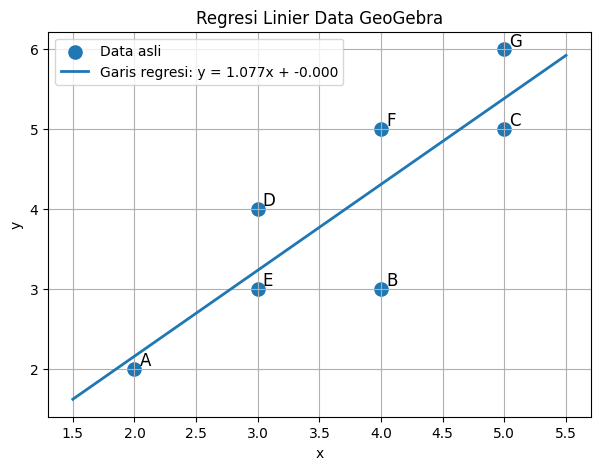

In [11]:
plt.figure(figsize=(7, 5))

plt.scatter(df["x"], df["y"], s=90, label="Data asli")

# Membuat garis regresi
x_line = np.linspace(df["x"].min() - 0.5, df["x"].max() + 0.5, 100)
y_line = model.predict(x_line.reshape(-1, 1))

plt.plot(x_line, y_line, linewidth=2, label=f"Garis regresi: y = {m_sklearn:.3f}x + {b_sklearn:.3f}")

for i, row in df.iterrows():
    plt.text(row["x"] + 0.04, row["y"] + 0.04, row["Titik"], fontsize=12)

plt.title("Regresi Linier Data GeoGebra")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

Garis regresi tersebut adalah garis yang meminimalkan jumlah kuadrat error antara nilai asli dan nilai prediksi.

## 10. Visualisasi residual/error

Residual adalah jarak antara titik data asli dengan garis regresi.

Jika residual kecil, berarti prediksi model dekat dengan nilai asli.

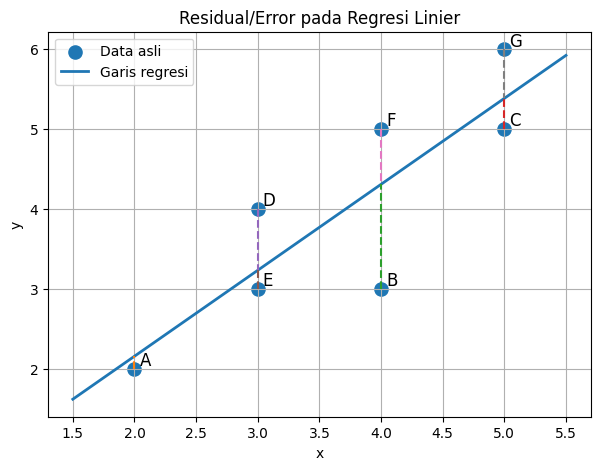

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(df_hasil["x"], df_hasil["y"], s=90, label="Data asli")
plt.plot(x_line, y_line, linewidth=2, label="Garis regresi")

# Garis residual dari y asli ke y prediksi
for i, row in df_hasil.iterrows():
    plt.plot([row["x"], row["x"]], [row["y"], row["y_prediksi"]], linestyle="--")
    plt.text(row["x"] + 0.04, row["y"] + 0.04, row["Titik"], fontsize=12)

plt.title("Residual/Error pada Regresi Linier")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

Grafik residual menunjukkan jarak vertikal antara titik asli dan garis regresi. Jarak inilah yang diminimalkan oleh metode **least squares**.

## 11. Evaluasi sederhana model regresi

Untuk melihat kualitas model, digunakan beberapa ukuran:

### Mean Squared Error atau MSE

$$
MSE = \frac{1}{n}\sum (y_i - \hat{y}_i)^2
$$

MSE menunjukkan rata-rata kuadrat error. Semakin kecil nilainya, semakin baik model.

### Root Mean Squared Error atau RMSE

$$
RMSE = \sqrt{MSE}
$$

RMSE adalah akar dari MSE sehingga satuannya kembali sama dengan data \(y\).

### R-squared atau \(R^2\)

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
$$

Nilai \(R^2\) menunjukkan seberapa besar variasi data \(y\) dapat dijelaskan oleh model.

In [13]:
y_pred = model.predict(X_sklearn)

mse = metrics.mean_squared_error(y_sklearn, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_sklearn, y_pred)

print("MSE  =", mse)
print("RMSE =", rmse)
print("R^2  =", r2)

MSE  = 0.4835164835164836
RMSE = 0.6953534953651154
R^2  = 0.7179487179487178


Interpretasi hasil evaluasi:

- Nilai \(R^2 \approx 0.7273\).
- Artinya sekitar **72.73% variasi nilai y** dapat dijelaskan oleh nilai x menggunakan model regresi linier ini.
- Sisanya sekitar **27.27%** dipengaruhi oleh faktor lain atau error data.

## 12. Perbandingan y asli dan y prediksi

Grafik berikut membandingkan nilai `y asli` dan `y prediksi` untuk setiap titik.

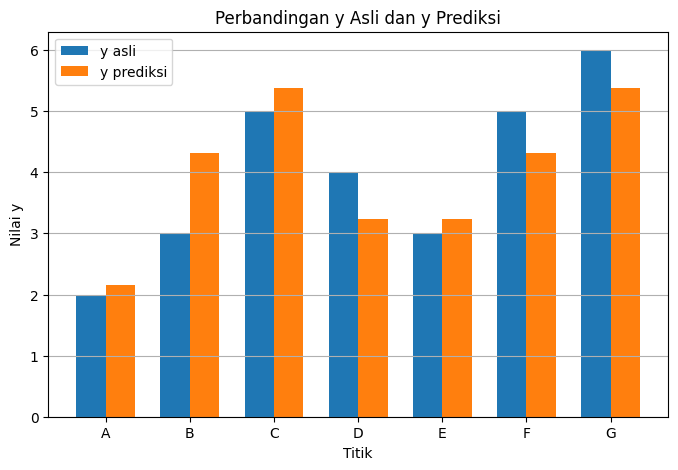

In [14]:
plt.figure(figsize=(8, 5))

index = np.arange(len(df_hasil))
width = 0.35

plt.bar(index - width/2, df_hasil["y"], width, label="y asli")
plt.bar(index + width/2, df_hasil["y_prediksi"], width, label="y prediksi")

plt.xticks(index, df_hasil["Titik"])
plt.title("Perbandingan y Asli dan y Prediksi")
plt.xlabel("Titik")
plt.ylabel("Nilai y")
plt.grid(axis="y")
plt.legend()
plt.show()

## 13. Matriks korelasi sederhana

Karena hanya ada dua variabel yaitu $x$ dan $y$, matriks korelasi digunakan untuk melihat kekuatan hubungan linier antara keduanya.

Nilai korelasi berada pada rentang -1 sampai 1:

- Mendekati 1 berarti hubungan positif kuat.
- Mendekati -1 berarti hubungan negatif kuat.
- Mendekati 0 berarti hubungan linier lemah.

In [15]:
corr = df[["x", "y"]].corr()
corr

,x,y
x,1.000000,0.847319
y,0.847319,1.000000


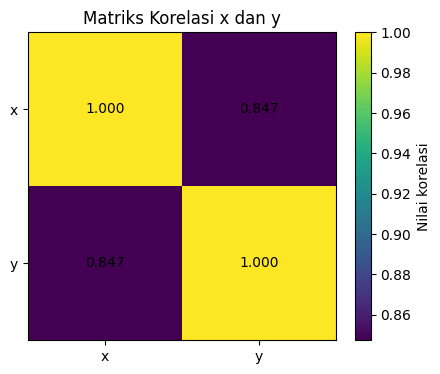

In [16]:
plt.figure(figsize=(5, 4))
plt.imshow(corr, interpolation="nearest")
plt.colorbar(label="Nilai korelasi")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.3f}", ha="center", va="center")

plt.title("Matriks Korelasi x dan y")
plt.show()

Nilai korelasi antara $x$ dan $y$ bernilai positif, sehingga hubungan kedua variabel searah: ketika $x$ naik, $y$ cenderung ikut naik.

## 14. Kesimpulan akhir

Berdasarkan data dari GeoGebra:

$$
(2,2), (4,3), (5,5), (3,4), (3,3), (4,5), (5,6)
$$

diperoleh hasil regresi linier:

$$
\boxed{\hat{y} = 1.076923x}
$$

Dengan nilai:

$$
\beta_0 = 0
$$

$$
\beta_1 = 1.076923
$$

Artinya:

- Intercept model adalah 0.
- Koefisien regresi/slope adalah 1.076923.
- Jika nilai \(x\) naik 1 satuan, maka nilai prediksi \(y\) naik sekitar 1.076923 satuan.
- Model memiliki nilai \(R^2 \approx 0.7273\), sehingga hubungan linier antara $x$ dan $y$ cukup baik untuk data ini.

Hasil perhitungan manual, rumus matriks, dan `sklearn` menghasilkan nilai koefisien yang sama.